<a href="https://colab.research.google.com/github/arhamk15/physics-projects/blob/main/Numerical_Integration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
l = 10
samples = 50000
points_in_circle = 0

# Store the points in lists
x_points = []
y_points = []
colors = [] # To store color based on whether the point is inside or outside the circle

for i in range(samples):
    x = np.random.uniform(-l, l)
    y = np.random.uniform(-l, l)
    x_points.append(x)
    y_points.append(y)

    if x**2 + y**2 < l**2:
        points_in_circle += 1
        colors.append('blue') # Color for points inside the circle
    else:
        colors.append('red') # Color for points outside the circle


ratio = points_in_circle / samples

print('The value of pi is :', 4 * ratio)

The value of pi is : 3.13424


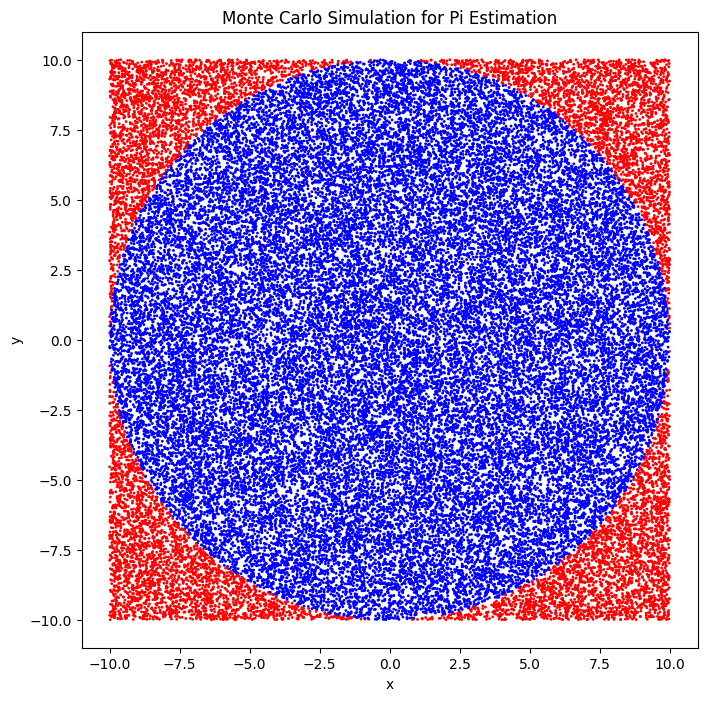

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(x_points, y_points, c=colors, s=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Monte Carlo Simulation for Pi Estimation')
plt.gca().set_aspect('equal', adjustable='box') # Set aspect ratio to equal
plt.show()

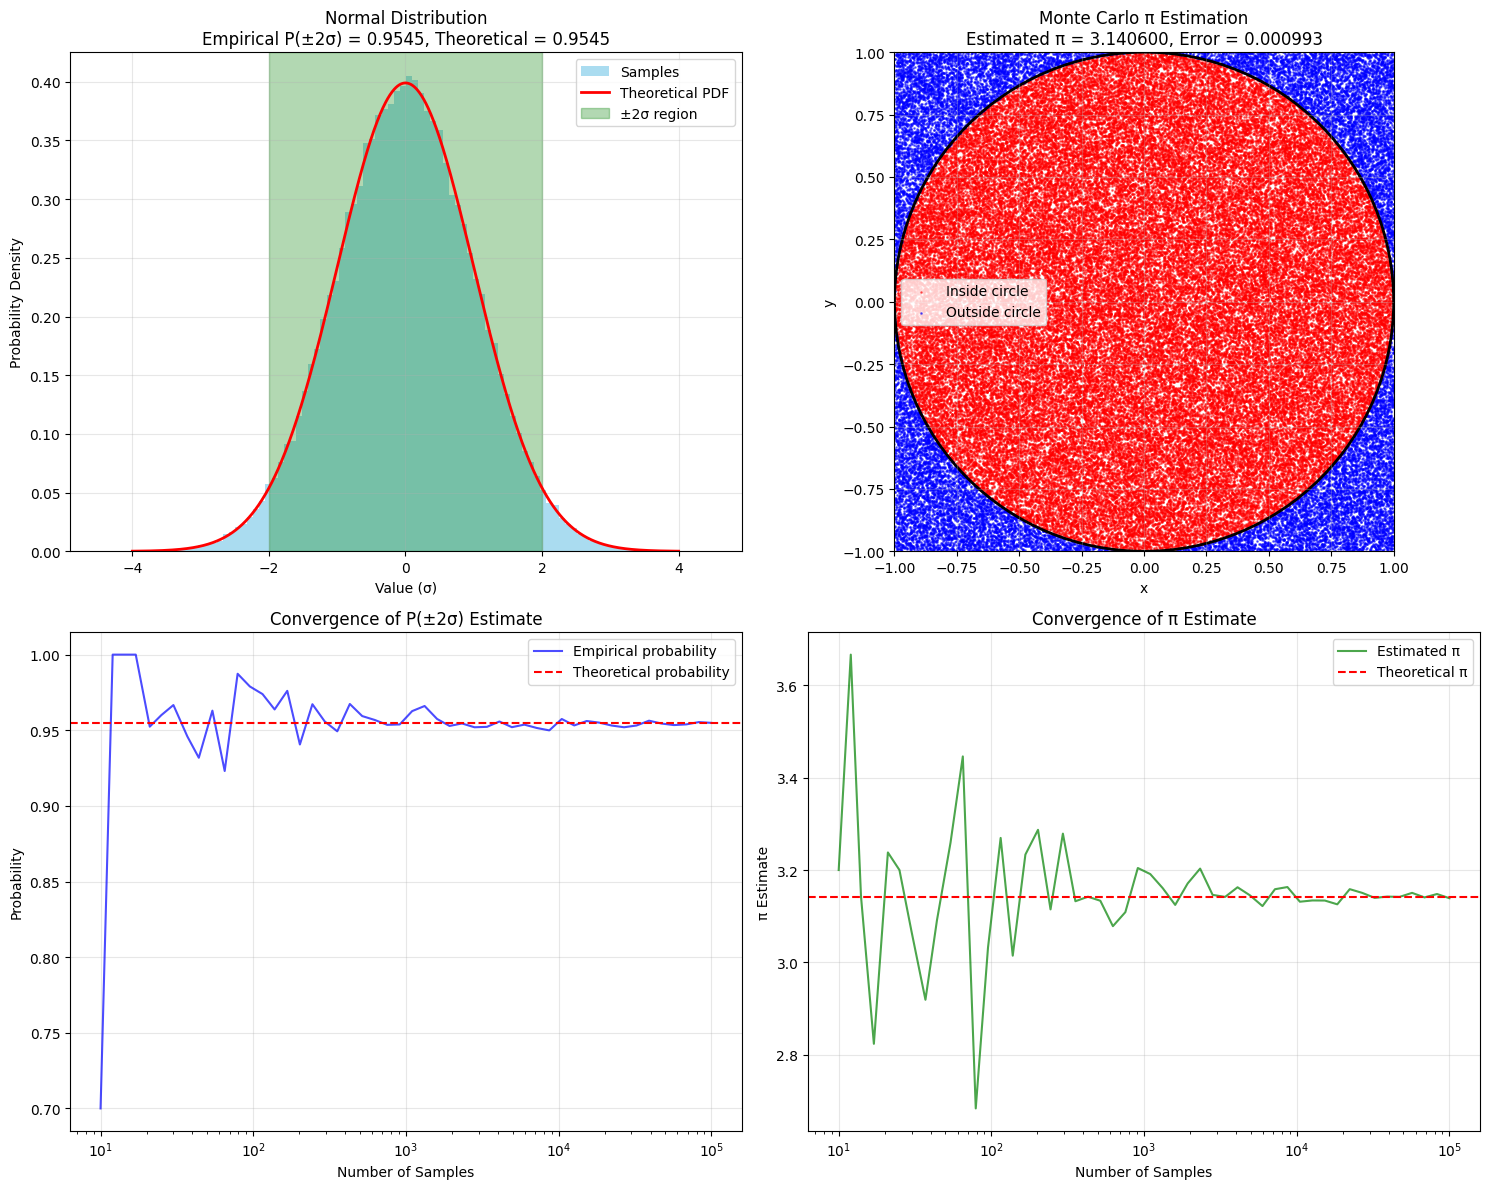

MONTE CARLO SIMULATION RESULTS
Normal Distribution Analysis:
  Empirical P(±2σ): 0.954470
  Theoretical P(±2σ): 0.954500
  Absolute Error: 0.000030
  Relative Error: 0.0031%

π Estimation:
  Estimated π: 3.140600
  Theoretical π: 3.141593
  Absolute Error: 0.000993
  Relative Error: 0.0316%

Plot saved as 'monte_carlo_results.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Set random seed for reproducibility
np.random.seed(42)

def monte_carlo_normal_probability(num_samples=100000):
    """
    Estimate the probability that normally distributed measurements
    lie within ±2σ of the mean using Monte Carlo simulation.
    """
    # Generate random samples from standard normal distribution
    samples = np.random.normal(0, 1, num_samples)

    # Count samples within ±2σ
    within_2sigma = np.sum((samples >= -2) & (samples <= 2))

    # Calculate probability
    probability = within_2sigma / num_samples

    # Theoretical probability for comparison
    theoretical_prob = stats.norm.cdf(2) - stats.norm.cdf(-2)

    return probability, theoretical_prob, samples

def monte_carlo_pi_estimation(num_samples=100000):
    """
    Estimate the value of π using Monte Carlo simulation.
    """
    # Generate random points in a unit square
    x = np.random.uniform(-1, 1, num_samples)
    y = np.random.uniform(-1, 1, num_samples)

    # Calculate distance from origin
    distances = np.sqrt(x**2 + y**2)

    # Count points inside the unit circle
    inside_circle = np.sum(distances <= 1)

    # Estimate π (area of circle / area of square * 4)
    pi_estimate = (inside_circle / num_samples) * 4

    return pi_estimate, x, y, distances

# Run simulations
num_samples = 100000

# Normal distribution simulation
prob_empirical, prob_theoretical, normal_samples = monte_carlo_normal_probability(num_samples)

# π estimation simulation
pi_estimate, x_coords, y_coords, distances = monte_carlo_pi_estimation(num_samples)

# Create a figure with subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Histogram of normal distribution with ±2σ region
ax1.hist(normal_samples, bins=100, density=True, alpha=0.7, color='skyblue', label='Samples')
x_range = np.linspace(-4, 4, 1000)
ax1.plot(x_range, stats.norm.pdf(x_range), 'r-', linewidth=2, label='Theoretical PDF')
ax1.axvspan(-2, 2, alpha=0.3, color='green', label='±2σ region')
ax1.set_xlabel('Value (σ)')
ax1.set_ylabel('Probability Density')
ax1.set_title(f'Normal Distribution\nEmpirical P(±2σ) = {prob_empirical:.4f}, Theoretical = {prob_theoretical:.4f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Monte Carlo π estimation
inside_circle = distances <= 1
outside_circle = distances > 1

ax2.scatter(x_coords[inside_circle], y_coords[inside_circle],
           c='red', alpha=0.5, s=1, label='Inside circle')
ax2.scatter(x_coords[outside_circle], y_coords[outside_circle],
           c='blue', alpha=0.5, s=1, label='Outside circle')

# Draw the unit circle
circle = plt.Circle((0, 0), 1, fill=False, color='black', linewidth=2)
ax2.add_patch(circle)

ax2.set_xlim(-1, 1)
ax2.set_ylim(-1, 1)
ax2.set_aspect('equal')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title(f'Monte Carlo π Estimation\nEstimated π = {pi_estimate:.6f}, Error = {abs(pi_estimate - np.pi):.6f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Convergence of normal probability estimate
sample_sizes = np.logspace(1, 5, 50).astype(int)
prob_convergence = []

for size in sample_sizes:
    samples = np.random.normal(0, 1, size)
    within_2sigma = np.sum((samples >= -2) & (samples <= 2))
    prob_convergence.append(within_2sigma / size)

ax3.semilogx(sample_sizes, prob_convergence, 'b-', alpha=0.7, label='Empirical probability')
ax3.axhline(y=prob_theoretical, color='r', linestyle='--', label='Theoretical probability')
ax3.set_xlabel('Number of Samples')
ax3.set_ylabel('Probability')
ax3.set_title('Convergence of P(±2σ) Estimate')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Convergence of π estimate
pi_convergence = []

for size in sample_sizes:
    x = np.random.uniform(-1, 1, size)
    y = np.random.uniform(-1, 1, size)
    inside = np.sum(np.sqrt(x**2 + y**2) <= 1)
    pi_convergence.append((inside / size) * 4)

ax4.semilogx(sample_sizes, pi_convergence, 'g-', alpha=0.7, label='Estimated π')
ax4.axhline(y=np.pi, color='r', linestyle='--', label='Theoretical π')
ax4.set_xlabel('Number of Samples')
ax4.set_ylabel('π Estimate')
ax4.set_title('Convergence of π Estimate')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()

# Save the plot
plt.savefig('monte_carlo_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Print results
print("=" * 60)
print("MONTE CARLO SIMULATION RESULTS")
print("=" * 60)
print(f"Normal Distribution Analysis:")
print(f"  Empirical P(±2σ): {prob_empirical:.6f}")
print(f"  Theoretical P(±2σ): {prob_theoretical:.6f}")
print(f"  Absolute Error: {abs(prob_empirical - prob_theoretical):.6f}")
print(f"  Relative Error: {abs(prob_empirical - prob_theoretical)/prob_theoretical*100:.4f}%")
print()
print(f"π Estimation:")
print(f"  Estimated π: {pi_estimate:.6f}")
print(f"  Theoretical π: {np.pi:.6f}")
print(f"  Absolute Error: {abs(pi_estimate - np.pi):.6f}")
print(f"  Relative Error: {abs(pi_estimate - np.pi)/np.pi*100:.4f}%")
print()
print(f"Plot saved as 'monte_carlo_results.png'")

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal

# Number of random points
N = 10000

# Generate uniform random 2D points in range [-5, 5] × [-5, 5]
points = np.random.uniform(-5, 5, size=(N, 2))

# Define Gaussian parameters
mean = np.array([0, 0])
cov = np.array([[1.0, 0.0],
                [0.0, 1.0]])

# Build Gaussian object
gaussian = multivariate_normal(mean=mean, cov=cov)

# Evaluate Gaussian probability density at each point
pdf_values = gaussian.pdf(points)

# Choose a PDF threshold to define "inside" the Gaussian
# e.g. inside = points whose density is greater than a cutoff
threshold = 0.1

inside_mask = pdf_values > threshold
num_inside = np.sum(inside_mask)

print(f"Total points: {N}")
print(f"Points inside Gaussian (pdf > {threshold}): {num_inside}")


Total points: 10000
Points inside Gaussian (pdf > 0.1): 281
